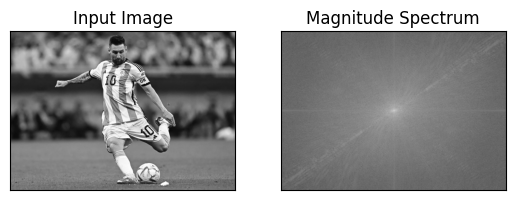

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('messi.png', cv2.IMREAD_GRAYSCALE)
# for discrete fourier transform
dft = cv2.dft(np.float32(img),flags=cv2.DFT_COMPLEX_OUTPUT) # Calculating frequencies
dft_shift = np.fft.fftshift(dft) # helps to shift frerquncies into the center of image
# This provide us the frequency transform which will be a complex array
# Input will be gray scaled dft
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1])) # Taking magnitude from dft_shift of the real and complex number

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum"), plt.xticks([]), plt.yticks([])
plt.show()
# As a resultans low frequnecy will be in the middle

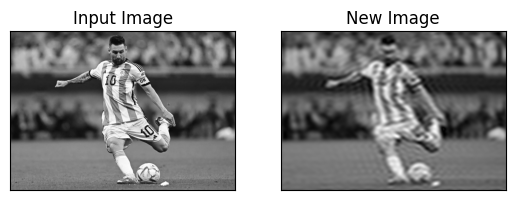

In [4]:
# Now we've to do inverse dft into it
# Now what if we want to remove high filters form it
# Then we need to pass this through Low Pass Filter, this blurs the image (noise)

rows, cols = img.shape
crow, ccol = rows//2, cols//2

# creating a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows, cols, 2), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# Apply mask and inverse DFT
fshift = dft_shift*mask 
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('New Image'), plt.xticks([]), plt.yticks([])
plt.show()
